# Wave-Front Tracking for ARZ  —  machine-precision ground truth

The ARZ analogue of `WFT-algorithm.ipynb` (scalar LWR). The homogeneous
Aw–Rascle–Zhang system

$$\rho_t + (\rho v)_x = 0,\qquad (\rho w)_t + (\rho w\,v)_x = 0,\qquad v = w - p(\rho)$$

has two wave families: a **genuinely-nonlinear 1-wave** ($\lambda_1 = v - \rho\,p'(\rho)$,
shock or rarefaction) and a **linearly-degenerate 2-contact** ($\lambda_2 = v$). Two
exact Riemann invariants: $w$ is constant across the 1-wave, $v$ is constant across
the 2-contact.

This notebook compares several solvers against the exact Riemann solution. Below is
exactly **how each scheme is implemented** in the codebase.

### `wft` — wave-front tracking  (`hyperbolic_pde/arz/wft_arz.py`)
The solution is a finite set of straight-line **fronts**, each separating two
piecewise-constant states $(\rho_l,w_l)\,|\,(\rho_r,w_r)$ and moving at an **exact**
speed — there is **no spatial grid, hence zero numerical diffusion**.
* **Riemann decomposition** (`riemann_fronts`): from $(L,R)$ compute the star state
  ($w_*=w_L$, $v_*=v_R$, $p(\rho_*)=w_L-v_R$). Emit a **1-shock** front at its
  Rankine–Hugoniot speed $s=(\rho_*v_*-\rho_Lv_L)/(\rho_*-\rho_L)$ if Lax says shock,
  else a **rarefaction fan** of small fronts (one per $\rho$-step of size `rare_delta`,
  each at the local $\lambda_1$); then a **2-contact** front at speed $v_*$.
* **Evolution**: advance every front $x \mathrel{+}= s\,\Delta t$ to the next
  collision, then **re-solve the exact Riemann problem** between the outer states of
  each cluster of fronts that just met (`_resolve_collisions_at_current_time`).
* **Only error source** = `rare_delta` (fan discretization); shocks & contacts are
  exact to machine precision. So WFT is the **ground truth** for piecewise-constant
  data, including multi-segment ICs where no closed form exists.

### `hll` — first-order HLL  (`reference_arz.solve_arz_reference`, `flux_scheme='hll'`)
Finite volume on the conserved $(\rho, y{=}\rho w)$ with the **HLL** two-wave flux:
estimate outer speeds $S_L=\min(\lambda_1^L,\lambda_1^R)$, $S_R=\max(\lambda_2^L,
\lambda_2^R)$ and average everything between them into **one** intermediate state.
Cheap and robust but **smears the 2-contact** (the middle wave is averaged away →
the characteristic velocity overshoot you see in the $v$ field). Strang-split exact
relaxation source; here $\tau=\infty$ so the source is off.

### `hllc` — first-order HLLC  (`flux_scheme='hllc'`)
HLL **plus the restored contact wave**. ARZ makes the contact speed exact in closed
form: $S_*=v_R$, with $w_*=w_L$ across the 1-wave. One intermediate (star) state
$\rho_*=\rho_L(S_L-v_L)/(S_L-S_*)$, $y_*=\rho_*w_L$, Toro flux
$F_*=F_L+S_L(U_*-U_L)$. Sharp contact at first order; falls back to HLL on any
non-finite. (Not in the default scheme list below — pass `schemes=(...,'hllc')`.)

### `muscl` — 2nd-order MUSCL-Hancock + HLLC  (`reference_arz.solve_arz_muscl`)
Second-order finite volume:
1. **minmod-limited reconstruction** of primitive $(\rho, v)$ to cell faces (limited
   there so a sharp contact doesn't ring into $v$), $\rho$ floored for vacuum safety;
2. **Hancock half-step** predictor (evolve faces by $\Delta t/2$ with the in-cell flux
   difference, no Riemann solve);
3. **HLLC** flux between the predicted face states; conservative update.
Robust (never NaNs), ~2× sharper than HLL, ~10× cheaper than WENO5.

### `weno5` — 5th-order WENO + SSP-RK3  (`reference_arz.solve_arz_weno5`)
Component-wise **WENO5** reconstruction on conserved $(\rho,y)$ with a **global
Lax–Friedrichs** flux split ($\alpha=\max|\lambda|$) and SSP-RK3 time stepping. High
order on smooth parts, but the global-LF split is diffusive and the lack of a
characteristic decomposition makes it **oscillatory / unstable on extreme states**
(it can NaN — its failure mode is caught and shown as `CRASH`). Run at low CFL (0.2).

---
Imports the tested solver from `hyperbolic_pde.arz.wft_arz` (verified in
`tests/test_wft_arz.py`: exact vs the analytic Riemann solver, mass-conserving, FV
schemes converge to it).

In [1]:
import sys
sys.path.insert(0, '..')   # repo root

import numpy as np
import matplotlib.pyplot as plt

from hyperbolic_pde.arz import physics_arz as P
from hyperbolic_pde.arz.riemann_arz import solve_riemann_arz_xt
from hyperbolic_pde.arz.wft_arz import (
    ArzFrontTracking, solve_arz_wft_xt, solve_arz_wft_riemann_xt)
from hyperbolic_pde.arz import reference_arz as Ref

# Pressure closure: 'rho' (linear, the prho default) or 'rho+rho2' (AR).
P.set_pressure_form('rho')
print('pressure_form =', P.get_pressure_form())

pressure_form = rho


## 1. A single Riemann problem — fronts & space-time diagram

Build the front decomposition of one Riemann problem and draw its space-time 
(x–t) front diagram, exactly like the LWR notebook. Each line is one front; 
the 1-wave (shock = single line, rarefaction = a fan) is followed by the 
2-contact.

In [2]:
# Left / right primitive states (rho, v).
rhoL, vL = 0.75, 0.25     # rho decreases L->R across the 1-wave -> rarefaction
rhoR, vR = 0.25, 0.65
x0 = 0.5
T  = 0.6

solver = ArzFrontTracking(boundaries=[x0], states=[(rhoL, vL), (rhoR, vR)],
                          rare_delta=0.03)
segments, history = solver.simulate(T)

print(f'{len(solver.fronts)} fronts at t=0 (incl. rarefaction fan slivers):')
for fr in ArzFrontTracking(boundaries=[x0],
                           states=[(rhoL, vL), (rhoR, vR)],
                           rare_delta=0.03).fronts:
    print(f'  {fr.kind:9s}  x={fr.x:.3f}  s={fr.s:+.4f}  L=(rho={fr.rho_l:.3f}, w={fr.w_l:.3f})  R=(rho={fr.rho_r:.3f}, w={fr.w_r:.3f})')

15 fronts at t=0 (incl. rarefaction fan slivers):
  rare1      x=0.500  s=-0.4714  L=(rho=0.750, w=1.000)  R=(rho=0.721, w=1.000)
  rare1      x=0.500  s=-0.4143  L=(rho=0.721, w=1.000)  R=(rho=0.693, w=1.000)
  rare1      x=0.500  s=-0.3571  L=(rho=0.693, w=1.000)  R=(rho=0.664, w=1.000)
  rare1      x=0.500  s=-0.3000  L=(rho=0.664, w=1.000)  R=(rho=0.636, w=1.000)
  rare1      x=0.500  s=-0.2429  L=(rho=0.636, w=1.000)  R=(rho=0.607, w=1.000)
  rare1      x=0.500  s=-0.1857  L=(rho=0.607, w=1.000)  R=(rho=0.579, w=1.000)
  rare1      x=0.500  s=-0.1286  L=(rho=0.579, w=1.000)  R=(rho=0.550, w=1.000)
  rare1      x=0.500  s=-0.0714  L=(rho=0.550, w=1.000)  R=(rho=0.521, w=1.000)
  rare1      x=0.500  s=-0.0143  L=(rho=0.521, w=1.000)  R=(rho=0.493, w=1.000)
  rare1      x=0.500  s=+0.0429  L=(rho=0.493, w=1.000)  R=(rho=0.464, w=1.000)
  rare1      x=0.500  s=+0.1000  L=(rho=0.464, w=1.000)  R=(rho=0.436, w=1.000)
  rare1      x=0.500  s=+0.1571  L=(rho=0.436, w=1.000)  R=(rho=0.407,

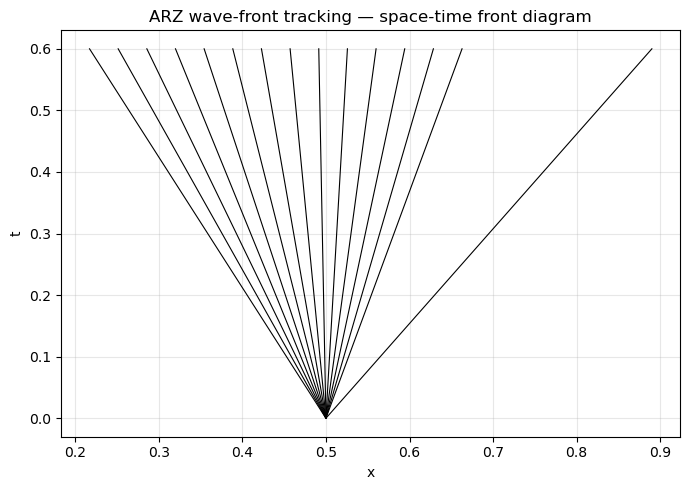

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for t0, xa, t1, xb in segments:
    ax.plot([xa, xb], [t0, t1], 'k-', lw=0.8)
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('ARZ wave-front tracking — space-time front diagram')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Reusable heatmap plotters

Two helpers used throughout the rest of the notebook:

* **`plot_riemann_case`** — a single Riemann problem `(rhoL,vL)|(rhoR,vR)`. 
  Plots x–t heatmaps of (ρ, v, w) for WFT next to the **exact** analytic 
  solution, and (optionally) the FV schemes, with a shared colour scale per 
  field so the smearing is directly comparable.
* **`plot_multidisc_case`** — an arbitrary multi-discontinuity IC 
  `states=[(rho,v),...]`, `boundaries=[...]`. No analytic GT exists, so **WFT 
  is the reference**; plots WFT (ρ, v, w) heatmaps plus, optionally, 
  `|FV − WFT|` error heatmaps and the space-time front diagram.

Both return the computed fields so you can post-process.

In [4]:
CMAPS = {'rho': 'viridis', 'v': 'cividis', 'w': 'magma'}
LABELS = {'rho': r'$\rho$', 'v': r'$v$', 'w': r'$w$'}
_CFL = {'muscl': 0.4, 'weno5': 0.2, 'hll': 0.4, 'hllc': 0.4}


def _fv_full(scheme, rho0, w0, x_min, x_max, t_max, nt):
    """Full (nt,nx) (rho, v, w) for an FV scheme, or None if it fails."""
    cfl = _CFL.get(scheme, 0.4)
    try:
        with np.errstate(over='raise', invalid='raise', divide='raise'):
            if scheme == 'muscl':
                r, w = Ref.solve_arz_muscl(rho0, w0, x_min, x_max, t_max, nt,
                                           tau=1e9, cfl=cfl, boundary='ghost')
            elif scheme == 'weno5':
                r, w = Ref.solve_arz_weno5(rho0, w0, x_min, x_max, t_max, nt,
                                           tau=1e9, cfl=cfl, boundary='ghost')
            else:  # hll | hllc
                _, _, r, w = Ref.solve_arz_reference(
                    rho0, w0, x_min, x_max, t_max, nt_out=nt, tau=1e9,
                    cfl=cfl, boundary='ghost', refine=1, flux_scheme=scheme)
            if not (np.isfinite(r).all() and np.isfinite(w).all()):
                raise FloatingPointError('non-finite')
    except (FloatingPointError, RuntimeError, ZeroDivisionError):
        return None
    return {'rho': r, 'v': w - P.pressure(r), 'w': w}


def _cells_from_segments(states, boundaries, xm):
    si = np.searchsorted(boundaries, xm, side='right')
    rho0 = np.array([states[int(k)][0] for k in si], float)
    v0 = np.array([states[int(k)][1] for k in si], float)
    return rho0, v0

In [5]:
def plot_riemann_case(rhoL, vL, rhoR, vR, x0=0.5, t_max=0.4,
                      nx=256, nt=160, schemes=('wft', 'muscl', 'weno5', 'hll'),
                      rare_delta=0.002, fields=('rho', 'v', 'w'),
                      show_error=True, title=None):
    """x-t heatmaps for ONE Riemann problem.

    For each field: a VALUE row (exact GT + every scheme) and, if show_error, an
    |scheme - exact| ERROR row directly beneath it (the exact column of the error
    row is left blank). 'wft' comes from the front tracker; 'muscl'/'weno5'/'hll'/
    'hllc' from the FV solvers. Returns a dict of fields per scheme."""
    x_min, x_max = 0.0, 1.0
    xm = (np.arange(nx) + 0.5) * ((x_max - x_min) / nx)
    t = np.linspace(0.0, t_max, nt)
    wL = float(vL + P.pressure(np.array(rhoL)))
    wR = float(vR + P.pressure(np.array(rhoR)))

    rE, wE, vE = solve_riemann_arz_xt(rhoL, wL, rhoR, wR, xm, t, x0=x0)
    data = {'exact': {'rho': rE, 'v': vE, 'w': wE}}
    rho0 = np.where(xm <= x0, rhoL, rhoR).astype(float)
    v0 = np.where(xm <= x0, vL, vR).astype(float)
    w0 = v0 + P.pressure(rho0)
    for s in schemes:
        if s == 'wft':
            r, w, v = solve_arz_wft_riemann_xt(rhoL, vL, rhoR, vR, xm, t,
                                               x0=x0, rare_delta=rare_delta)
            data['wft'] = {'rho': r, 'v': v, 'w': w}
        else:
            data[s] = _fv_full(s, rho0, w0, x_min, x_max, t_max, nt)

    cols = ['exact'] + list(schemes)
    extent = [x_min, x_max, 0.0, t_max]
    # Rows: per field one value-row, plus one error-row if show_error.
    rows_per_field = 2 if show_error else 1
    nrow = len(fields) * rows_per_field
    fig, axes = plt.subplots(nrow, len(cols),
                             figsize=(2.9 * len(cols), 2.7 * nrow),
                             squeeze=False)
    for f_i, fld in enumerate(fields):
        g = data['exact'][fld]
        # shared value scale across exact + schemes
        vmin, vmax = float(g.min()), float(g.max())
        for c in cols:
            if data.get(c) is not None:
                vmin = min(vmin, float(data[c][fld].min()))
                vmax = max(vmax, float(data[c][fld].max()))
        if vmax - vmin < 1e-9:
            vmax = vmin + 1e-9
        # shared error scale across schemes (exclude exact)
        emax = 0.0
        for s in schemes:
            if data.get(s) is not None:
                emax = max(emax, float(np.abs(data[s][fld] - g).max()))
        emax = emax or 1e-9

        vrow = f_i * rows_per_field
        for c_i, c in enumerate(cols):
            ax = axes[vrow][c_i]
            f = None if data.get(c) is None else data[c][fld]
            if f is None:
                ax.text(0.5, 0.5, 'CRASH', ha='center', va='center',
                        color='red', transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                im = ax.imshow(f, origin='lower', aspect='auto', extent=extent,
                               cmap=CMAPS[fld], vmin=vmin, vmax=vmax)
            if vrow == 0:
                ax.set_title(c, fontsize=10)
            if c_i == 0:
                ax.set_ylabel(LABELS[fld] + ' value\nt', fontsize=9)
            ax.set_xlabel('x', fontsize=8)
        fig.colorbar(im, ax=axes[vrow].tolist(), fraction=0.02, pad=0.01)

        if show_error:
            erow = vrow + 1
            im_e = None
            for c_i, c in enumerate(cols):
                ax = axes[erow][c_i]
                if c == 'exact':
                    ax.axis('off')           # error of exact-vs-exact is trivially 0
                    continue
                f = None if data.get(c) is None else data[c][fld]
                if f is None:
                    ax.text(0.5, 0.5, 'CRASH', ha='center', va='center',
                            color='red', transform=ax.transAxes)
                    ax.set_xticks([]); ax.set_yticks([])
                else:
                    im_e = ax.imshow(np.abs(f - g), origin='lower', aspect='auto',
                                     extent=extent, cmap='magma', vmin=0.0, vmax=emax)
                if c_i == 0:
                    ax.set_ylabel(LABELS[fld] + ' |err|\nt', fontsize=9)
                ax.set_xlabel('x', fontsize=8)
            if im_e is not None:
                fig.colorbar(im_e, ax=axes[erow].tolist(), fraction=0.02, pad=0.01)
    ttl = title or (f'Riemann  L=({rhoL},{vL})  R=({rhoR},{vR})  '
                    f'p={P.get_pressure_form()}')
    fig.suptitle(ttl + '   (value rows + |scheme - exact| rows)', fontsize=12)
    plt.show()
    return data

In [6]:
def plot_multidisc_case(states, boundaries, t_max=0.5, nx=400, nt=200,
                        fv_schemes=('muscl', 'weno5', 'hll'),
                        rare_delta=0.003, fields=('rho', 'v', 'w'),
                        show_error=True, show_fronts=True, title=None):
    """x-t heatmaps for an arbitrary multi-discontinuity IC.

    No analytic GT exists for multi-segment data, so WFT IS the reference.
    Row 1: WFT (ρ, v, w). If show_error: one row per fv_scheme of |FV - WFT|
    (per field). If show_fronts: also the space-time front diagram.
    states=[(rho,v),...] (len n), boundaries=[...] (len n-1). Returns fields."""
    x_min, x_max = 0.0, 1.0
    xm = (np.arange(nx) + 0.5) * ((x_max - x_min) / nx)
    t = np.linspace(0.0, t_max, nt)
    extent = [x_min, x_max, 0.0, t_max]

    rW, wW, vW = solve_arz_wft_xt(states, boundaries, xm, t, rare_delta=rare_delta)
    wft = {'rho': rW, 'v': vW, 'w': wW}

    if show_fronts:
        solver = ArzFrontTracking(boundaries, states, rare_delta=max(rare_delta, 0.02))
        segs, _ = solver.simulate(t_max)
        figf, axf = plt.subplots(figsize=(6.5, 4.5))
        for t0, xa, t1, xb in segs:
            axf.plot([xa, xb], [t0, t1], 'k-', lw=0.5)
        axf.set_xlabel('x'); axf.set_ylabel('t')
        axf.set_title('front diagram (fronts collide & re-solve)')
        axf.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # Row 1: WFT fields.
    figh, axes = plt.subplots(1, len(fields), figsize=(2.9 * len(fields) + 2, 3.0),
                              squeeze=False)
    for c_i, fld in enumerate(fields):
        im = axes[0][c_i].imshow(wft[fld], origin='lower', aspect='auto',
                                 extent=extent, cmap=CMAPS[fld])
        axes[0][c_i].set_title('WFT (GT)  ' + LABELS[fld], fontsize=10)
        axes[0][c_i].set_xlabel('x'); axes[0][c_i].set_ylabel('t')
        figh.colorbar(im, ax=axes[0][c_i], fraction=0.046, pad=0.04)
    figh.suptitle(title or (f'multi-disc WFT  segments={len(states)}  '
                            f'p={P.get_pressure_form()}'), fontsize=12)
    plt.tight_layout(); plt.show()

    if show_error and fv_schemes:
        rho0, v0 = _cells_from_segments(states, boundaries, xm)
        w0 = v0 + P.pressure(rho0)
        nfields = len(fields)
        fige, axe = plt.subplots(len(fv_schemes), nfields,
                                 figsize=(2.9 * nfields + 2, 2.7 * len(fv_schemes)),
                                 squeeze=False)
        for r_i, s in enumerate(fv_schemes):
            fv = _fv_full(s, rho0, w0, x_min, x_max, t_max, nt)
            for c_i, fld in enumerate(fields):
                ax = axe[r_i][c_i]
                if fv is None:
                    ax.text(0.5, 0.5, 'CRASH', ha='center', va='center',
                            color='red', transform=ax.transAxes)
                    ax.set_xticks([]); ax.set_yticks([])
                else:
                    err = np.abs(fv[fld] - wft[fld])
                    im = ax.imshow(err, origin='lower', aspect='auto',
                                   extent=extent, cmap='magma', vmin=0.0)
                    fige.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                if r_i == 0:
                    ax.set_title('|.. - WFT|  ' + LABELS[fld], fontsize=10)
                if c_i == 0:
                    ax.set_ylabel(f'{s}\nt', fontsize=10)
                ax.set_xlabel('x', fontsize=8)
        fige.suptitle('FV error vs WFT (per scheme x field)', fontsize=12)
        plt.tight_layout(); plt.show()
    return wft

## 3. Riemann cases — one heatmap panel per case

The four canonical ARZ Riemann structures. In every panel WFT (3rd–5th columns 
vs `exact` in col 1) is visually identical to the exact GT; the FV schemes 
smear the fronts, HLL worst (watch the `v` field at a contact).

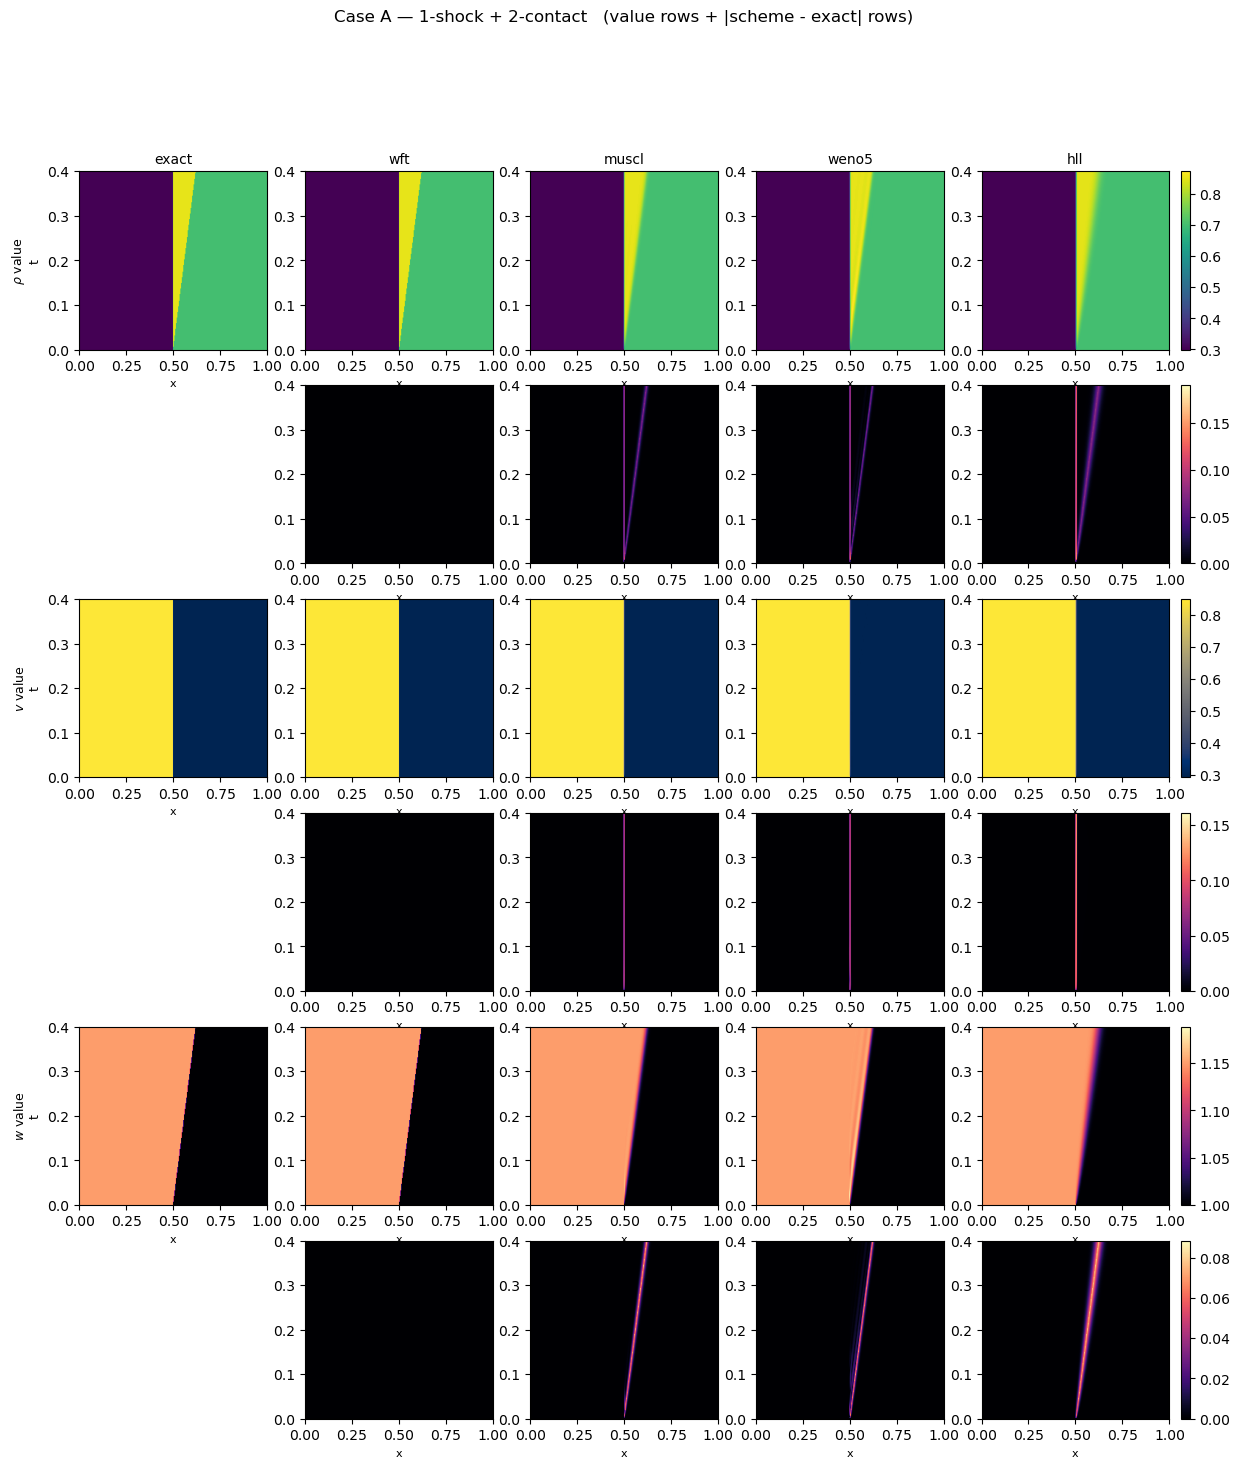

In [7]:
_ = plot_riemann_case(0.30, 0.85, 0.70, 0.30, title='Case A — 1-shock + 2-contact')

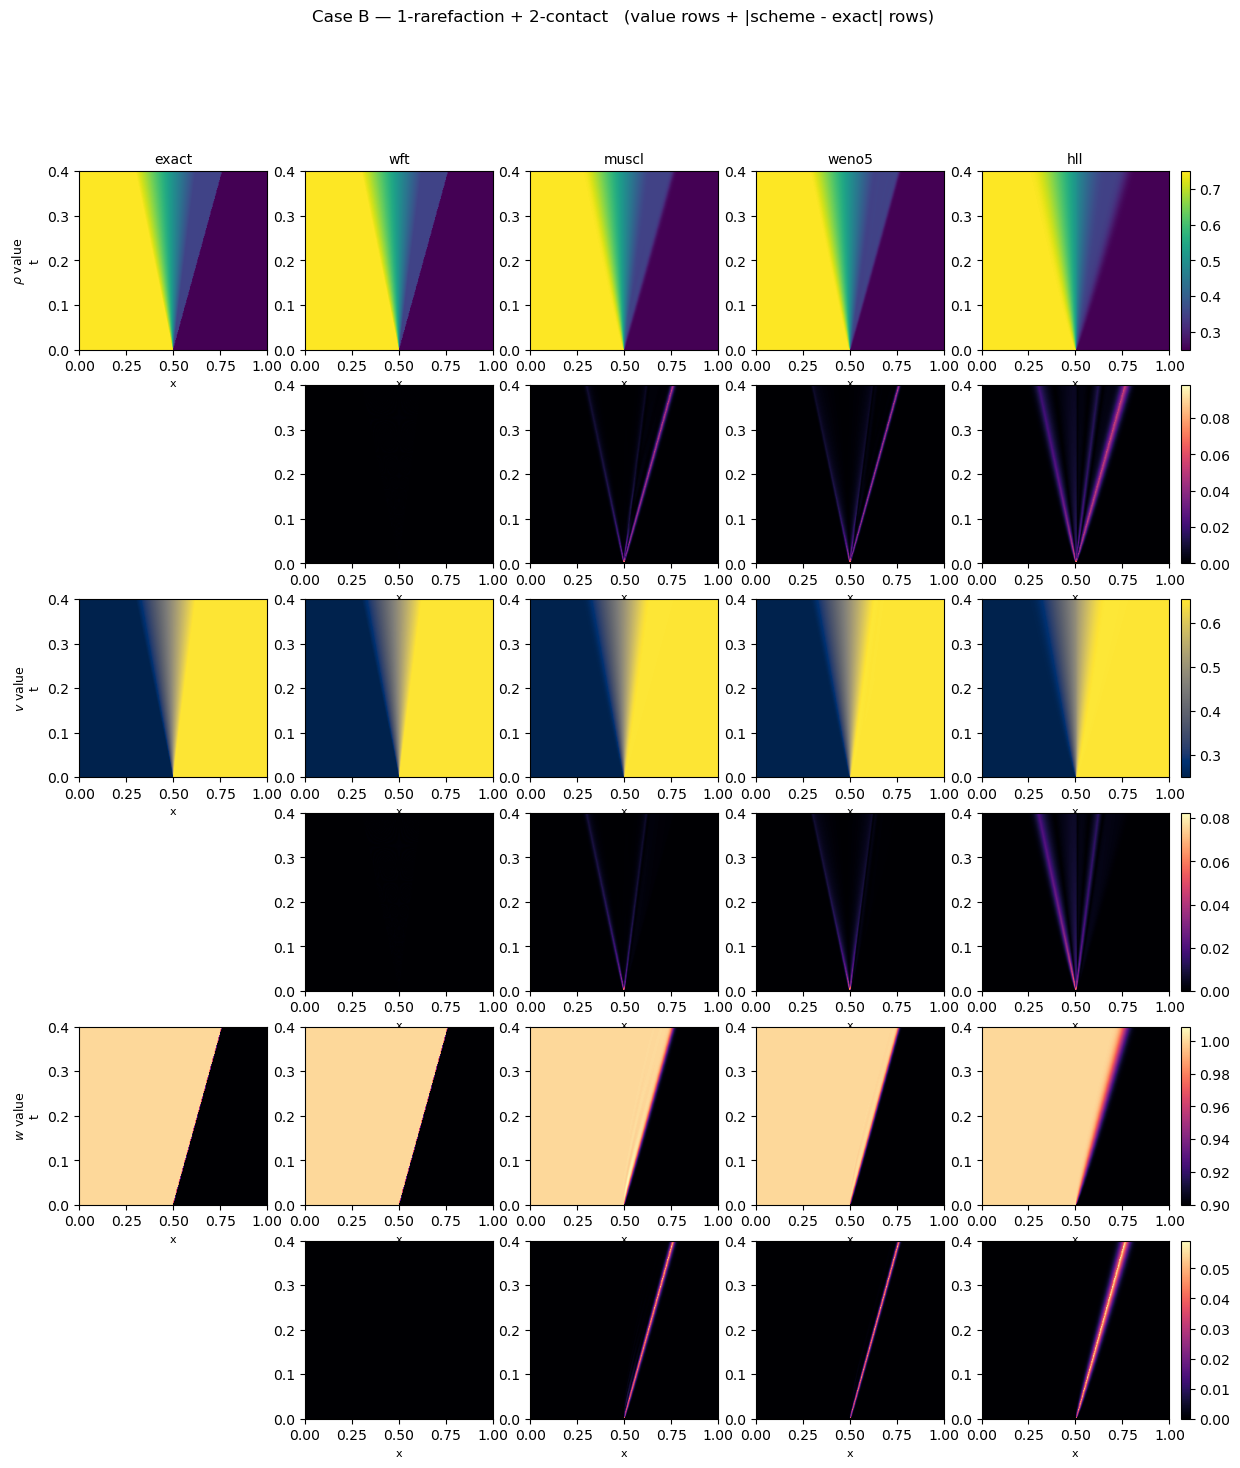

In [8]:
_ = plot_riemann_case(0.75, 0.25, 0.25, 0.65, title='Case B — 1-rarefaction + 2-contact')

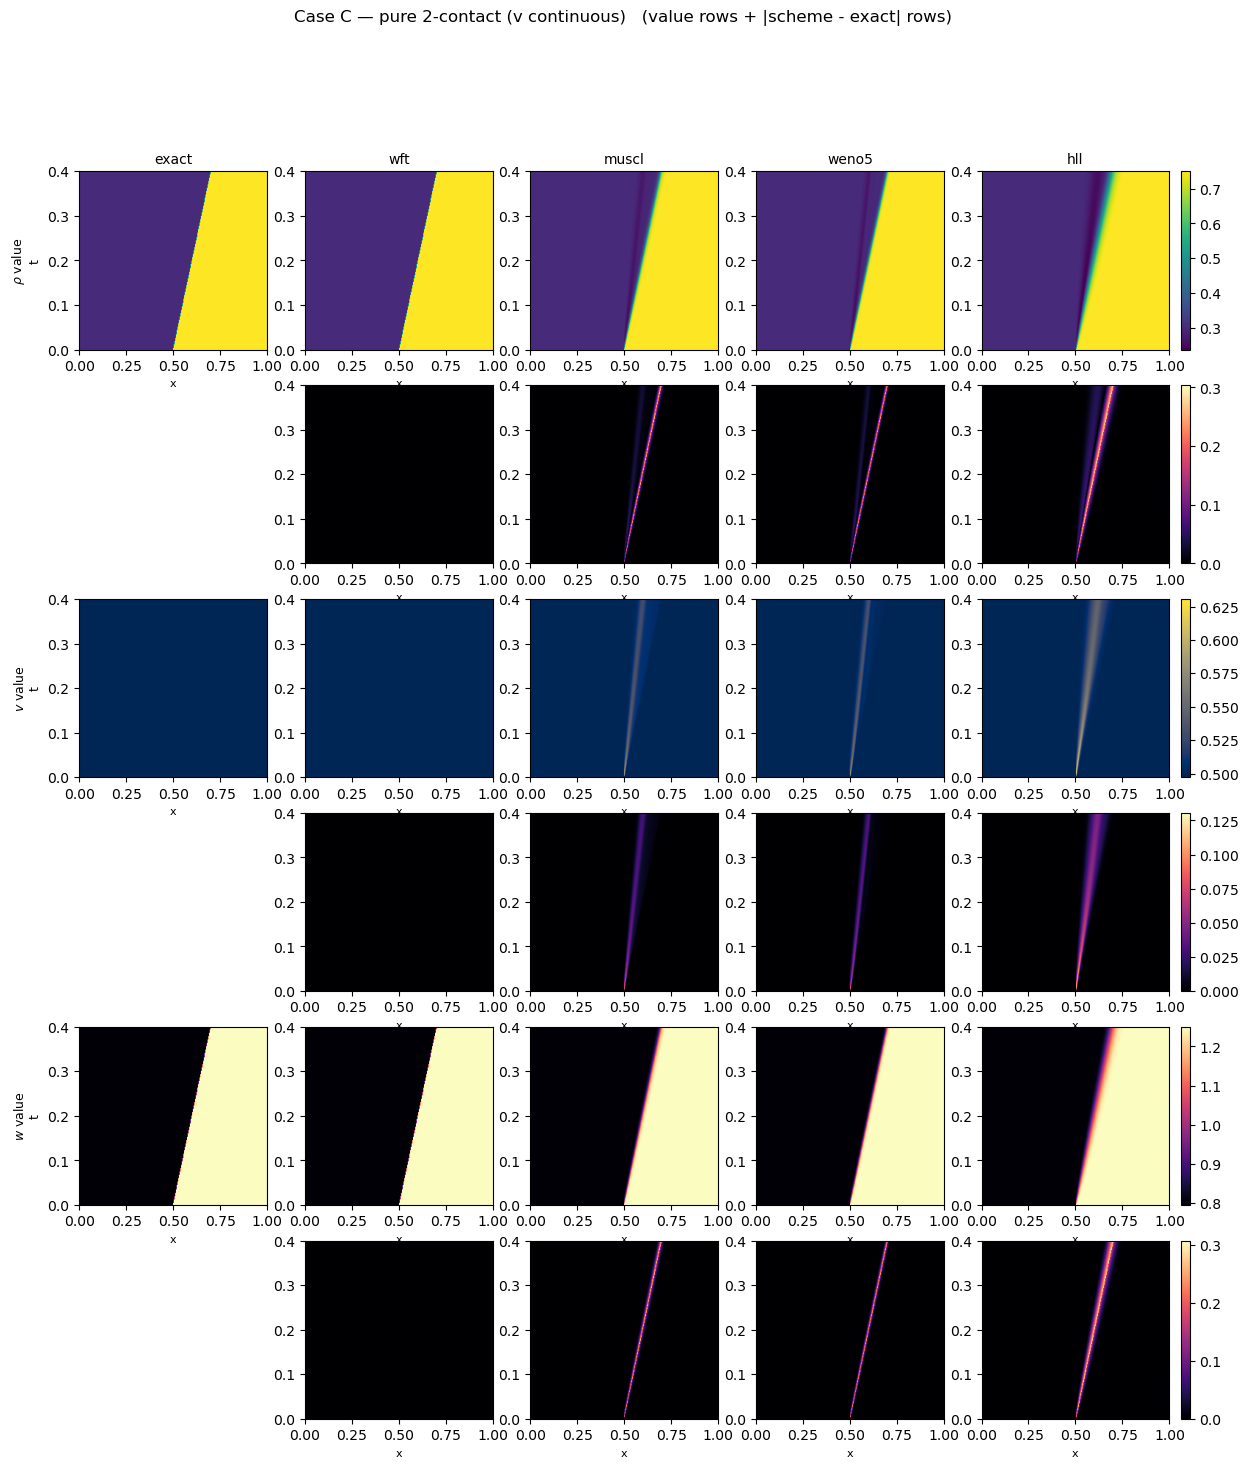

In [9]:
_ = plot_riemann_case(0.30, 0.50, 0.75, 0.50, title='Case C — pure 2-contact (v continuous)')

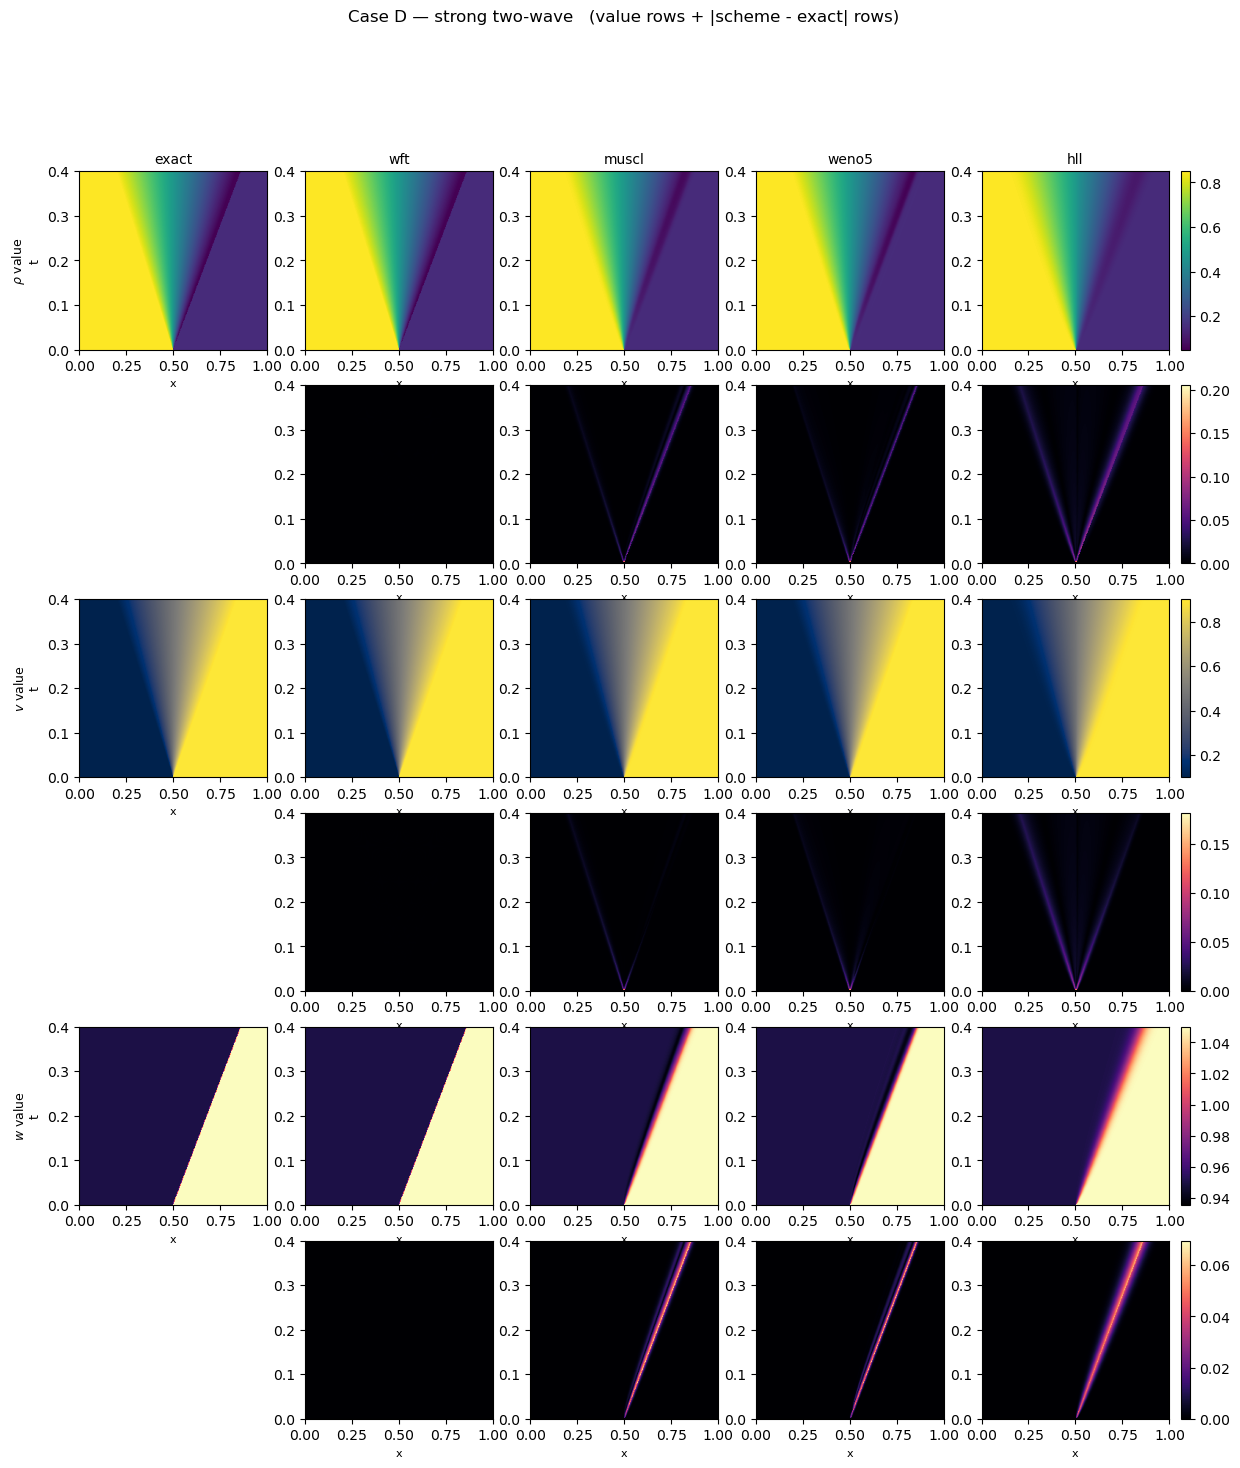

In [10]:
_ = plot_riemann_case(0.85, 0.10, 0.15, 0.90, title='Case D — strong two-wave')

## 4. Multi-discontinuity cases — one panel per case

Arbitrary piecewise-constant ICs whose waves interact (fronts collide and 
re-solve). WFT is the ground truth; the second figure per case shows 
`|FV − WFT|`, concentrated along the wave trajectories (brightest for HLL).

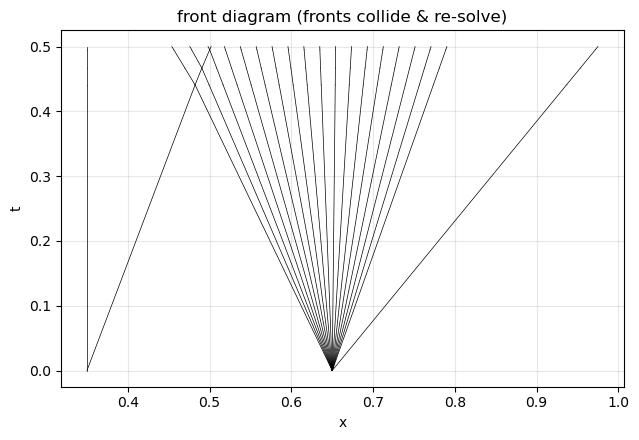

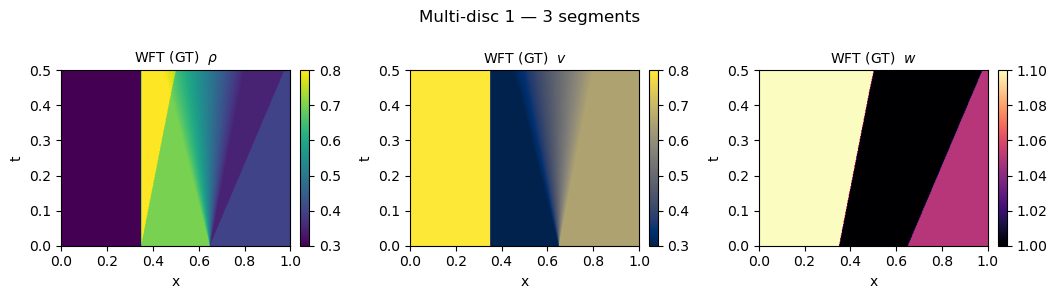

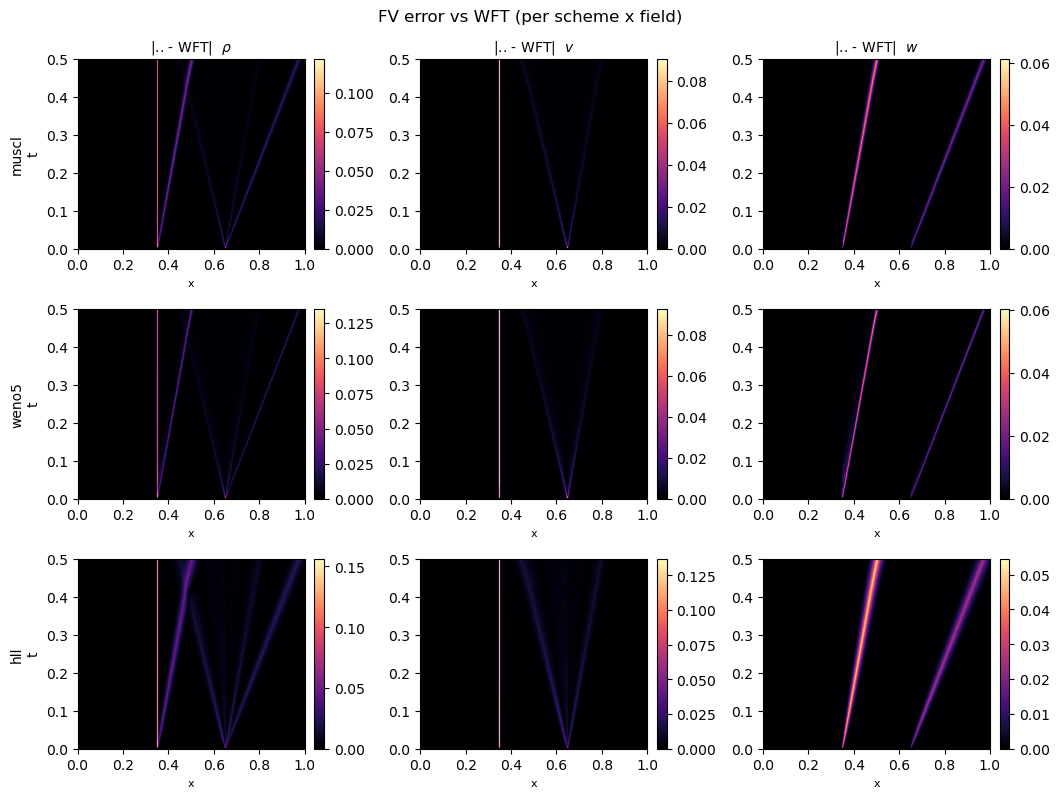

In [11]:
# Case 1 — 3 segments (two interfaces, one shock-like + one contact-like).
_ = plot_multidisc_case(
    states=[(0.30, 0.80), (0.70, 0.30), (0.40, 0.65)],
    boundaries=[0.35, 0.65],
    title='Multi-disc 1 — 3 segments')

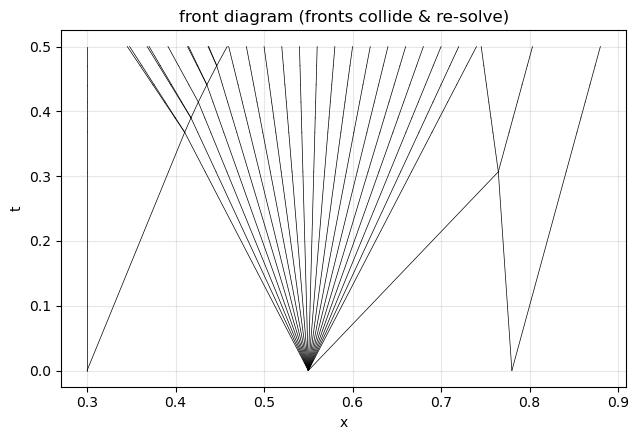

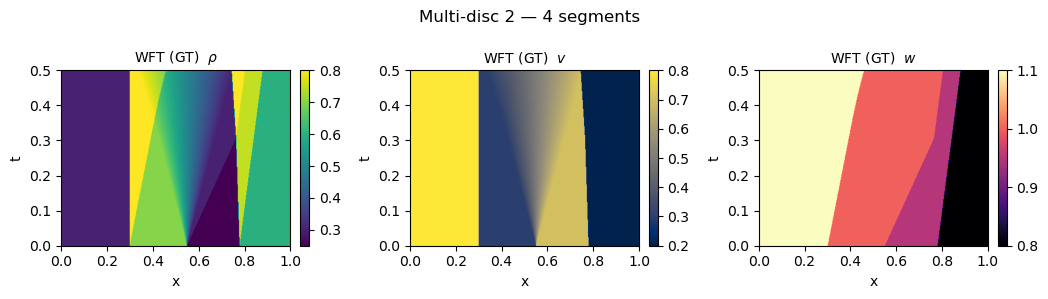

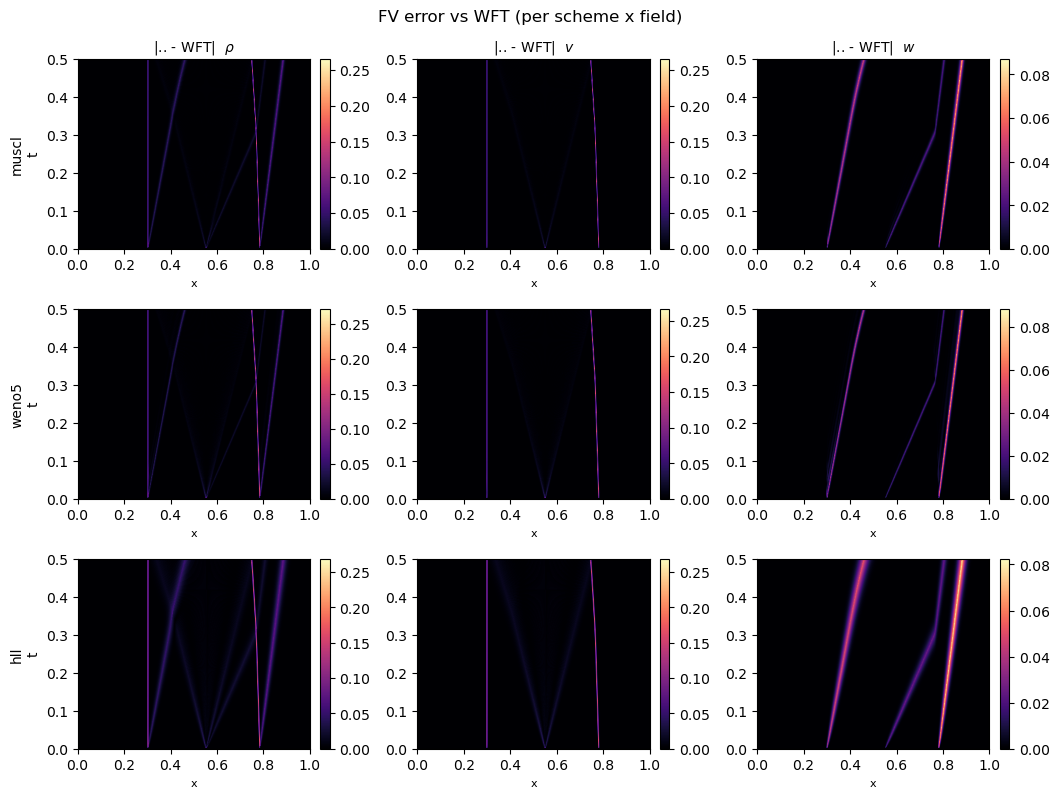

In [12]:
# Case 2 — 4 segments (richer interaction).
_ = plot_multidisc_case(
    states=[(0.30, 0.80), (0.70, 0.30), (0.25, 0.70), (0.60, 0.20)],
    boundaries=[0.30, 0.55, 0.78],
    title='Multi-disc 2 — 4 segments')

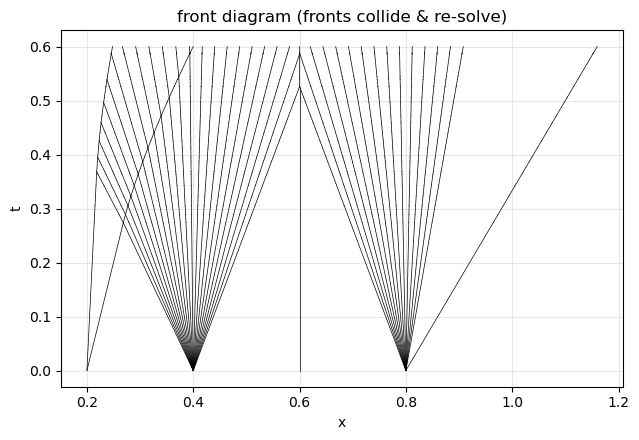

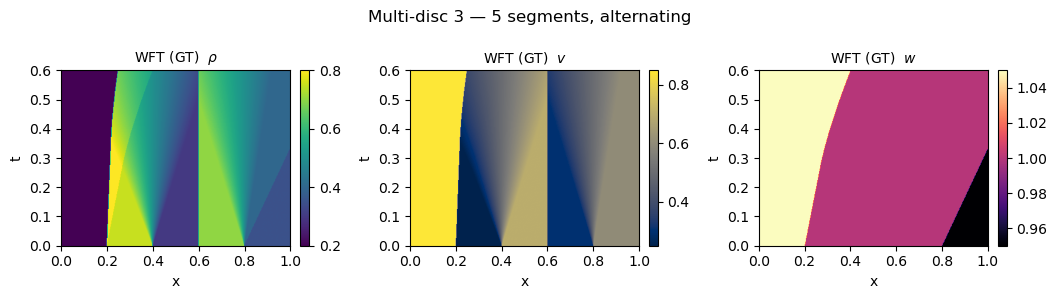

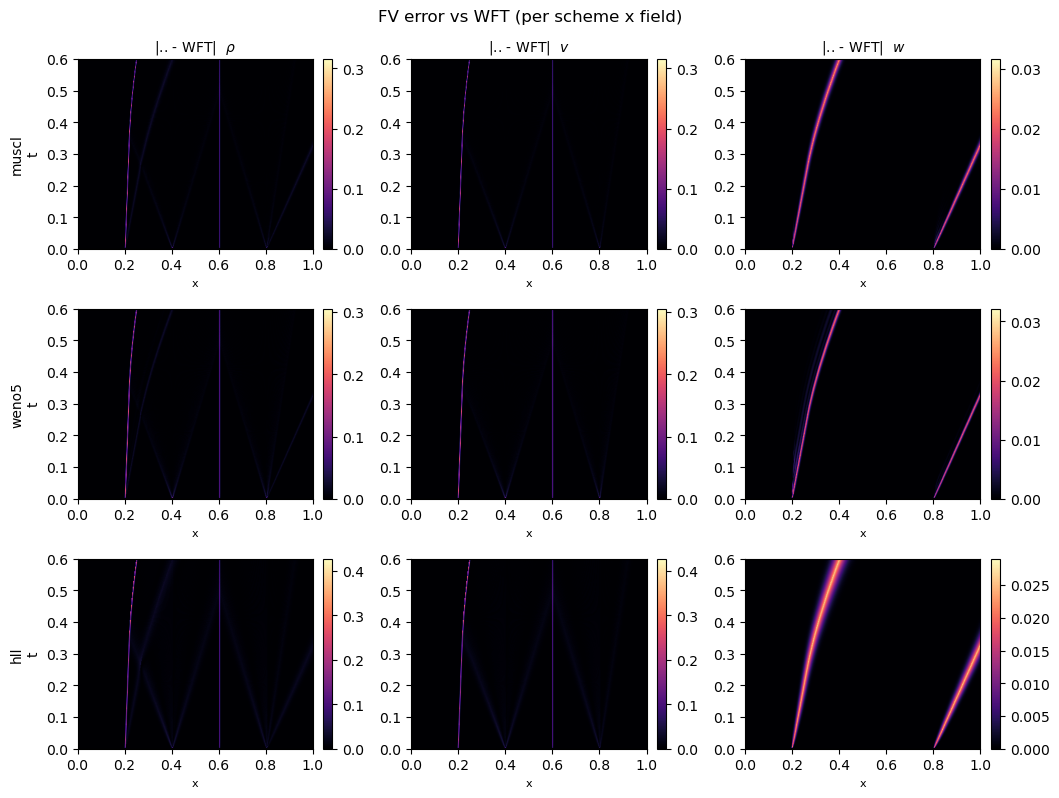

In [13]:
# Case 3 — 5 segments, alternating high/low density (many colliding fronts).
_ = plot_multidisc_case(
    states=[(0.20, 0.85), (0.75, 0.25), (0.30, 0.70),
            (0.70, 0.30), (0.35, 0.60)],
    boundaries=[0.2, 0.4, 0.6, 0.8],
    t_max=0.6,
    title='Multi-disc 3 — 5 segments, alternating')

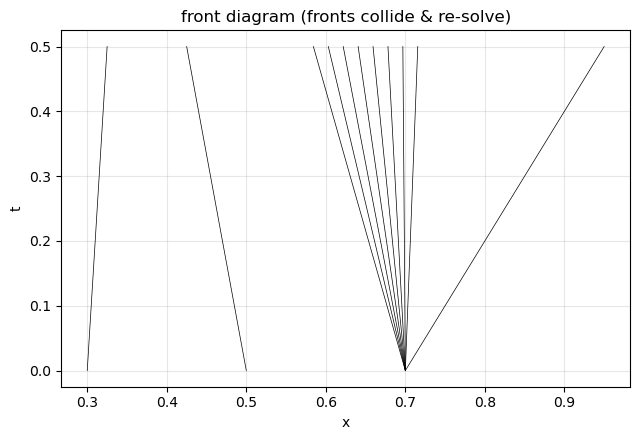

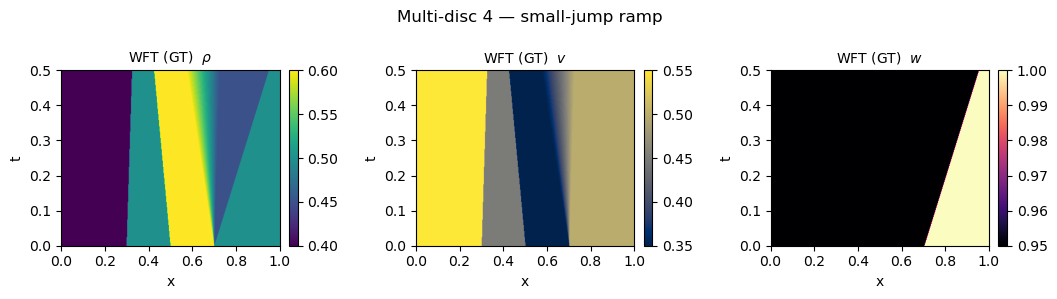

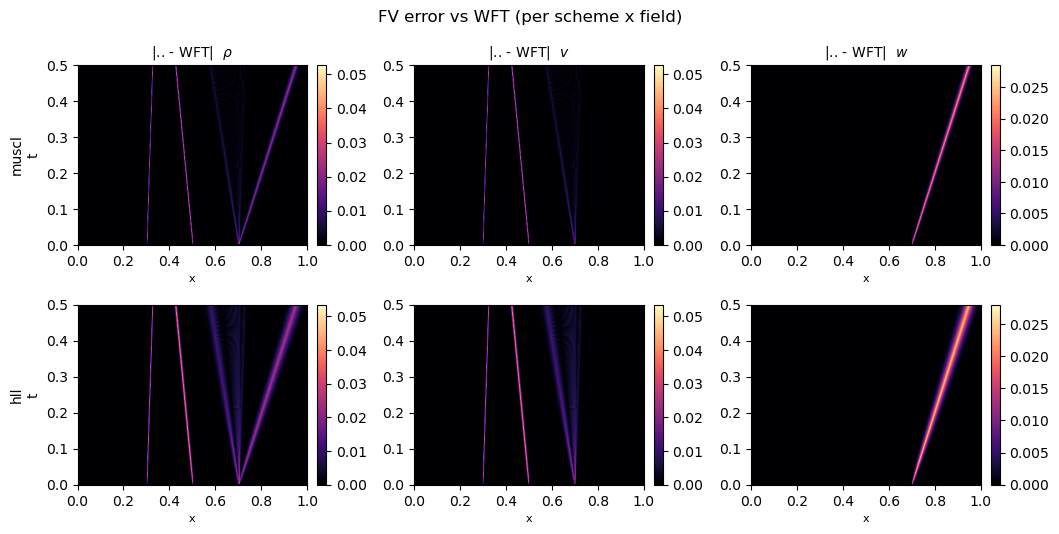

In [14]:
# Case 4 — a near-equilibrium ramp (small jumps) to show the weak-wave regime.
_ = plot_multidisc_case(
    states=[(0.40, 0.55), (0.50, 0.45), (0.60, 0.35), (0.50, 0.50)],
    boundaries=[0.3, 0.5, 0.7],
    fv_schemes=('muscl', 'hll'),
    title='Multi-disc 4 — small-jump ramp')

## 5. Convergence: rarefaction error → 0 with `rare_delta`

WFT's only error source is the rarefaction-fan discretization. On a problem 
with a 1-rarefaction the max error scales **linearly** in `rare_delta`; shocks 
and contacts stay exact regardless.

In [15]:
x = np.linspace(0.0, 1.0, 1000); t = np.array([0.4])
rhoL, vL, rhoR, vR, x0 = 0.75, 0.25, 0.25, 0.65, 0.5
wL = float(vL + P.pressure(np.array(rhoL))); wR = float(vR + P.pressure(np.array(rhoR)))
rE, _, _ = solve_riemann_arz_xt(rhoL, wL, rhoR, wR, x, t, x0=x0)
print(f'{"rare_delta":>11s} {"max|err| rho":>14s}')
for rd in (0.04, 0.02, 0.01, 0.005, 0.0025):
    rW, _, _ = solve_arz_wft_riemann_xt(rhoL, vL, rhoR, vR, x, t, x0=x0, rare_delta=rd)
    print(f'{rd:11.4f} {np.abs(rW-rE).max():14.3e}')

 rare_delta   max|err| rho
     0.0400      1.960e-02
     0.0200      9.615e-03
     0.0100      4.620e-03
     0.0050      2.122e-03
     0.0025      8.734e-04
